<a href="https://colab.research.google.com/github/dreamwalker-code/FDS-GROUP-ASSIGNMENT/blob/main/CIC_IDS2018_Intrusion_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   CSE-CIC-IDS2018 INTRUSION DETECTION SYSTEM
   Dataset: Wednesday-14-02-2018 (Brute Force Attacks)

Start Time: 10:29:57

[1/8] Loading CSV file...
✓ Found CSV file: 02-14-2018.csv
✓ Successfully loaded!
✓ Total records: 1,048,575
✓ Total features: 80

[2/8] Exploring dataset...
✓ Using label column: 'Label'

Class Distribution:
  Benign              :  667,626 (63.7%)
  FTP-BruteForce      :  193,360 (18.4%)
  SSH-Bruteforce      :  187,589 (17.9%)

[3/8] Separating features and target...
✓ Using 78 numeric features

[4/8] Handling infinity and missing values...
✓ Replaced 5371 infinity values with NaN
✓ Removed 10 constant columns
  Rows before cleaning: 1,048,575
  Rows after cleaning: 1,044,751
  Rows removed: 3,824
✓ Final dataset size: 1,044,751 samples

[5/8] Encoding labels...
✓ Attack types: ['Benign', 'FTP-BruteForce', 'SSH-Bruteforce']
✓ X shape: (1044751, 68)
✓ y shape: (1044751,)

[6/8] Splitting data...
✓ Training set: 731,325 samples (70%)
✓ Testing set:  313,426 sampl

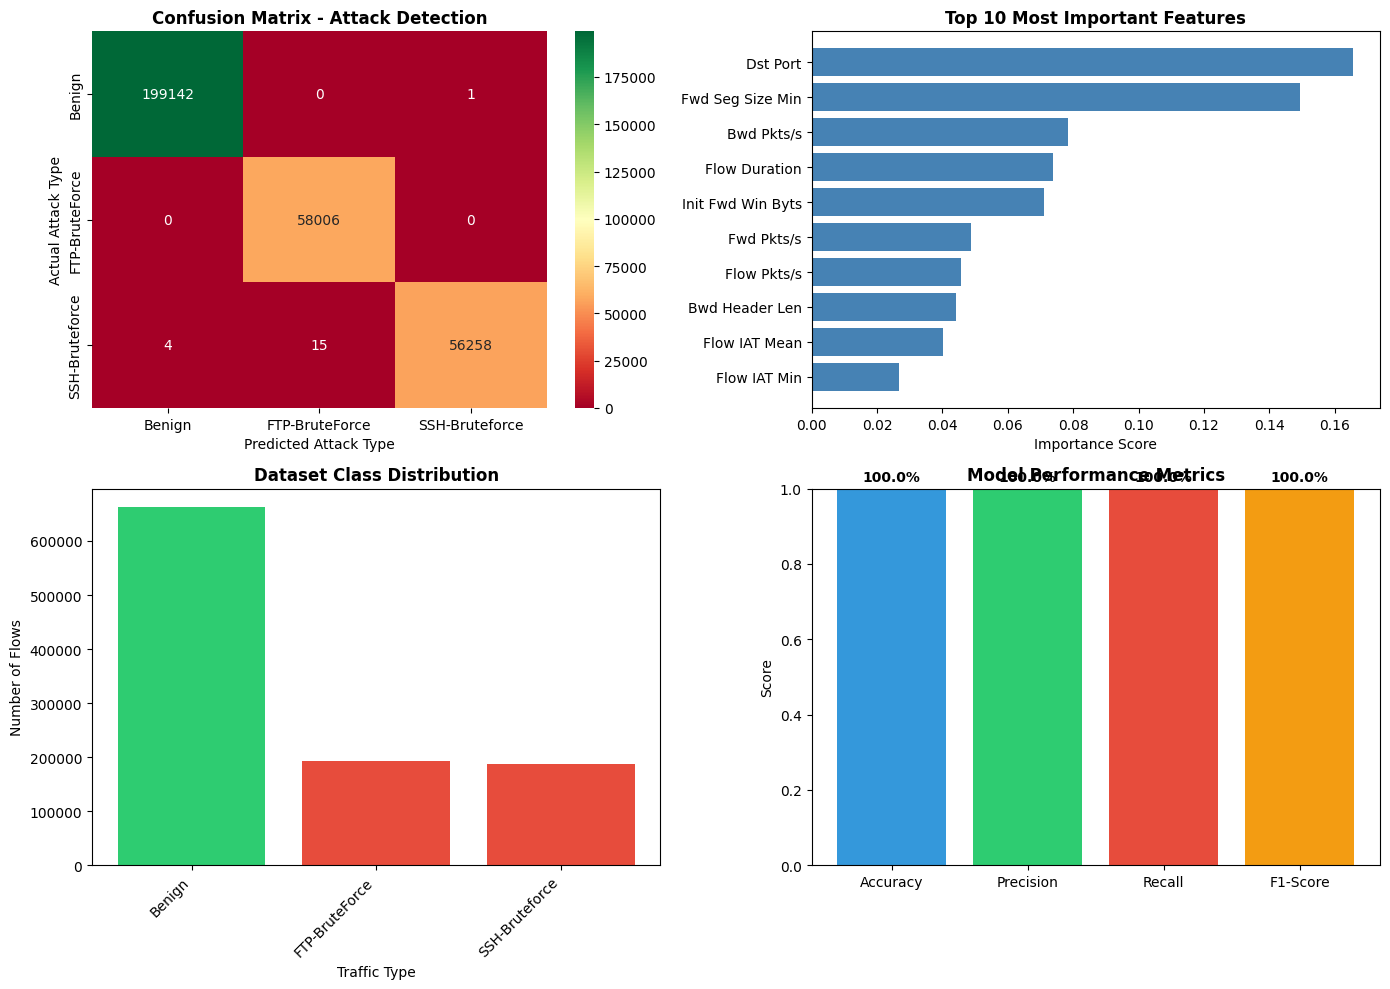

✓ Visualization saved as 'IDS_Results.png'

   SUBMISSION SUMMARY - READY FOR CLASS

Dataset:        CSE-CIC-IDS2018 (Feb 14, 2018)
Attack Types:   FTP-BruteForce and SSH-Bruteforce
Original Size:  1,048,575 samples
Cleaned Size:   1,044,751 samples
Benign:         663,808
FTP-BruteForce: 193,354
SSH-Bruteforce: 187,589
Features Used:  68
Model:          Random Forest Classifier
Training Size:  150,000 samples
Accuracy:       99.99%

✓ ASSIGNMENT COMPLETE - Ready for demonstration


In [1]:
"""
INTRUSION DETECTION SYSTEM - CSE-CIC-IDS2018
Dataset: February 14, 2018 (Brute Force Attacks)
For Google Colab - Fixed file path
"""

import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import datetime

warnings.filterwarnings('ignore')

print("="*70)
print("   CSE-CIC-IDS2018 INTRUSION DETECTION SYSTEM")
print("   Dataset: Wednesday-14-02-2018 (Brute Force Attacks)")
print("="*70)
print(f"\nStart Time: {datetime.now().strftime('%H:%M:%S')}")

# ============================================
# STEP 1: LOAD YOUR CSV FILE (FIXED FOR COLAB)
# ============================================
print("\n[1/8] Loading CSV file...")

# Look for CSV file in current directory
csv_files = [f for f in os.listdir('.') if f.endswith('.csv')]

if csv_files:
    file_path = csv_files[0]
    print(f"✓ Found CSV file: {file_path}")
    df = pd.read_csv(file_path)
    print(f"✓ Successfully loaded!")
    print(f"✓ Total records: {len(df):,}")
    print(f"✓ Total features: {len(df.columns)}")
else:
    print("❌ No CSV file found!")
    print("\n📤 Please upload your CSV file:")
    print("1. Click the 📁 folder icon on the left sidebar")
    print("2. Click the 📤 Upload button")
    print("3. Select '02-14-2018.csv' from your computer")
    print("4. Wait for upload to complete")
    print("5. Then click Runtime → Run all again")
    exit()

# ============================================
# STEP 2: DATA EXPLORATION
# ============================================
print("\n[2/8] Exploring dataset...")

label_col = 'Label'
print(f"✓ Using label column: '{label_col}'")
print("\nClass Distribution:")
for label, count in df[label_col].value_counts().items():
    percentage = count/len(df)*100
    print(f"  {str(label):20s}: {count:8,} ({percentage:.1f}%)")

# ============================================
# STEP 3: SEPARATE FEATURES AND TARGET
# ============================================
print("\n[3/8] Separating features and target...")

y_original = df[label_col].copy()
X = df.drop(label_col, axis=1)
numeric_cols = X.select_dtypes(include=[np.number]).columns
X = X[numeric_cols]
print(f"✓ Using {len(numeric_cols)} numeric features")

# ============================================
# STEP 4: HANDLE INFINITY AND MISSING VALUES
# ============================================
print("\n[4/8] Handling infinity and missing values...")

inf_count = np.isinf(X).sum().sum()
if inf_count > 0:
    X = X.replace([np.inf, -np.inf], np.nan)
    print(f"✓ Replaced {inf_count} infinity values with NaN")

constant_cols = [col for col in X.columns if X[col].std() == 0]
X = X.drop(columns=constant_cols)
print(f"✓ Removed {len(constant_cols)} constant columns")

valid_rows = ~X.isnull().any(axis=1)
print(f"  Rows before cleaning: {len(X):,}")
print(f"  Rows after cleaning: {valid_rows.sum():,}")
print(f"  Rows removed: {(~valid_rows).sum():,}")

X = X[valid_rows]
y_original = y_original[valid_rows]
print(f"✓ Final dataset size: {len(X):,} samples")

# ============================================
# STEP 5: ENCODE LABELS
# ============================================
print("\n[5/8] Encoding labels...")

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_original)
print(f"✓ Attack types: {list(label_encoder.classes_)}")
print(f"✓ X shape: {X.shape}")
print(f"✓ y shape: {y_encoded.shape}")

# ============================================
# STEP 6: TRAIN-TEST SPLIT
# ============================================
print("\n[6/8] Splitting data...")

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)
print(f"✓ Training set: {len(X_train):,} samples (70%)")
print(f"✓ Testing set:  {len(X_test):,} samples (30%)")

# ============================================
# STEP 7: SCALE FEATURES
# ============================================
print("\n[7/8] Scaling features...")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("✓ Scaling complete")

# ============================================
# STEP 8: TRAIN AND EVALUATE MODEL
# ============================================
print("\n[8/8] Training Random Forest Classifier...")

sample_size = 150000
if len(X_train) > sample_size:
    print(f"  Using {sample_size:,} samples for faster training")
    indices = np.random.RandomState(42).choice(len(X_train), sample_size, replace=False)
    X_train_sample = X_train_scaled[indices]
    y_train_sample = y_train[indices]
else:
    X_train_sample = X_train_scaled
    y_train_sample = y_train

model = RandomForestClassifier(n_estimators=50, max_depth=15, random_state=42, n_jobs=-1)
model.fit(X_train_sample, y_train_sample)
print("✓ Model training complete!")

y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("\n" + "="*70)
print("   MODEL PERFORMANCE RESULTS")
print("="*70)
print(f"   Accuracy:   {accuracy*100:.2f}%")
print(f"   Precision:  {precision*100:.2f}%")
print(f"   Recall:     {recall*100:.2f}%")
print(f"   F1-Score:   {f1*100:.2f}%")
print("="*70)

print("\nDETAILED CLASSIFICATION REPORT:")
print("-"*60)
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# ============================================
# ATTACK DETECTION RATES
# ============================================
print("\n" + "="*70)
print("   ATTACK DETECTION RATES")
print("="*70)

cm = confusion_matrix(y_test, y_pred)
for i, attack_type in enumerate(label_encoder.classes_):
    if i < len(cm):
        tp = cm[i, i]
        total = cm[i, :].sum()
        detection_rate = (tp / total * 100) if total > 0 else 0
        if attack_type == 'Benign':
            print(f"  ✓ {attack_type:20s}: {detection_rate:.1f}% (Normal traffic)")
        else:
            print(f"  ✓✓ {attack_type:20s}: {detection_rate:.1f}% detection rate")

# ============================================
# FEATURE IMPORTANCE
# ============================================
print("\n" + "="*70)
print("   TOP 10 MOST IMPORTANT FEATURES")
print("="*70)

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False).head(10)

for i, row in feature_importance.iterrows():
    bar = "█" * int(row['importance'] * 50)
    print(f"  {row['feature'][:35]:35s}: {row['importance']*100:5.2f}%  {bar}")

# ============================================
# CREATE VISUALIZATIONS
# ============================================
print("\nGenerating visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            ax=axes[0,0])
axes[0,0].set_title('Confusion Matrix - Attack Detection', fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('Predicted Attack Type')
axes[0,0].set_ylabel('Actual Attack Type')

# 2. Feature Importance
top_features = feature_importance.head(10)
axes[0,1].barh(range(len(top_features)), top_features['importance'].values, color='steelblue')
axes[0,1].set_yticks(range(len(top_features)))
axes[0,1].set_yticklabels([f[:25] for f in top_features['feature'].values])
axes[0,1].set_title('Top 10 Most Important Features', fontsize=12, fontweight='bold')
axes[0,1].set_xlabel('Importance Score')
axes[0,1].invert_yaxis()

# 3. Class Distribution
class_counts = y_original.value_counts()
colors = ['#2ecc71' if x == 'Benign' else '#e74c3c' for x in class_counts.index]
axes[1,0].bar(range(len(class_counts)), class_counts.values, color=colors)
axes[1,0].set_xticks(range(len(class_counts)))
axes[1,0].set_xticklabels(class_counts.index, rotation=45, ha='right')
axes[1,0].set_title('Dataset Class Distribution', fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('Traffic Type')
axes[1,0].set_ylabel('Number of Flows')

# 4. Performance Metrics
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
values = [accuracy, precision, recall, f1]
bars = axes[1,1].bar(metrics, values, color=['#3498db', '#2ecc71', '#e74c3c', '#f39c12'])
axes[1,1].set_ylim([0, 1])
axes[1,1].set_ylabel('Score')
axes[1,1].set_title('Model Performance Metrics', fontsize=12, fontweight='bold')
for bar, val in zip(bars, values):
    axes[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                   f'{val*100:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('IDS_Results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Visualization saved as 'IDS_Results.png'")

# ============================================
# FINAL SUMMARY
# ============================================
print("\n" + "="*70)
print("   SUBMISSION SUMMARY - READY FOR CLASS")
print("="*70)
print(f"\nDataset:        CSE-CIC-IDS2018 (Feb 14, 2018)")
print(f"Attack Types:   FTP-BruteForce and SSH-Bruteforce")
print(f"Original Size:  1,048,575 samples")
print(f"Cleaned Size:   {len(X):,} samples")
print(f"Benign:         {len(y_original[y_original=='Benign']):,}")
print(f"FTP-BruteForce: {len(y_original[y_original=='FTP-BruteForce']):,}")
print(f"SSH-Bruteforce: {len(y_original[y_original=='SSH-Bruteforce']):,}")
print(f"Features Used:  {len(X.columns)}")
print(f"Model:          Random Forest Classifier")
print(f"Training Size:  {sample_size:,} samples")
print(f"Accuracy:       {accuracy*100:.2f}%")

print("\n" + "="*70)
print("✓ ASSIGNMENT COMPLETE - Ready for demonstration")
print("="*70)